<a href="https://colab.research.google.com/github/PrishitaM/Classification_Techinques_Booking_Cancellation/blob/main/Classification_Techniques_Inn_hotels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
df = pd.read_csv("/content/INNHotelsGroup.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.shape

(36275, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

**EDA**

Univariate Analysis

booking status-

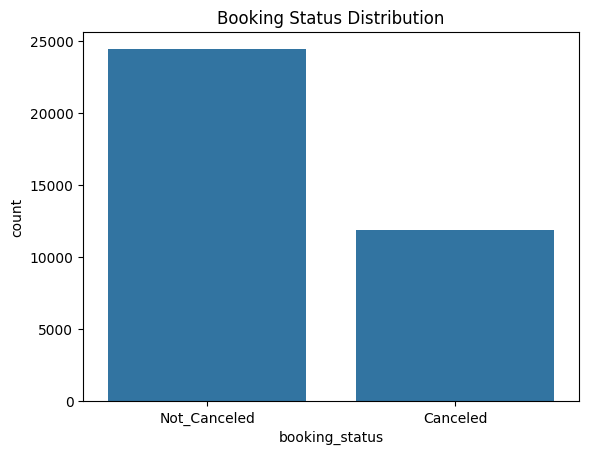

In [ ]:
sns.countplot(x='booking_status', data=df)
plt.title("Booking Status Distribution")
plt.show()

arrival month-

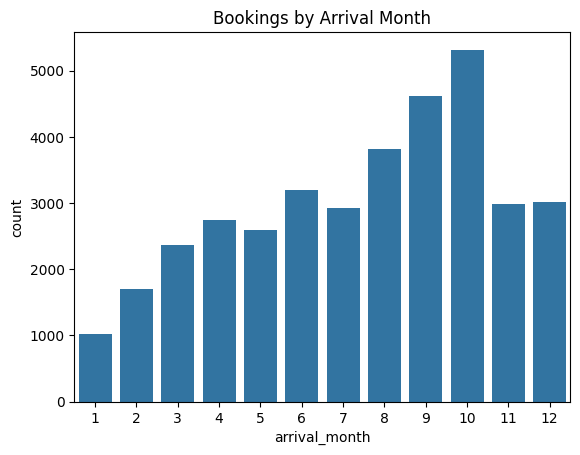

In [ ]:
sns.countplot(x='arrival_month', data=df)
plt.title("Bookings by Arrival Month")
plt.show()

Market Segment

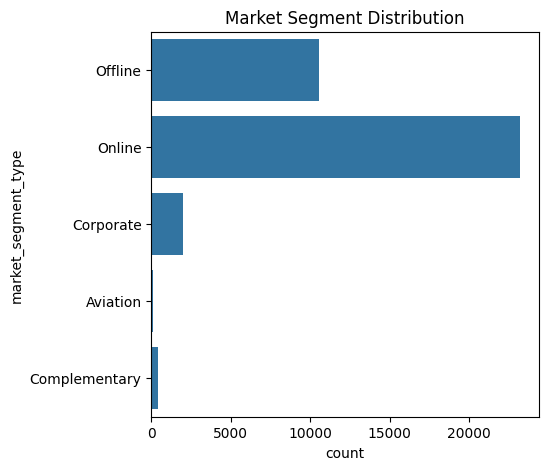

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(y='market_segment_type', data=df)
plt.title("Market Segment Distribution")
plt.show()

lead time

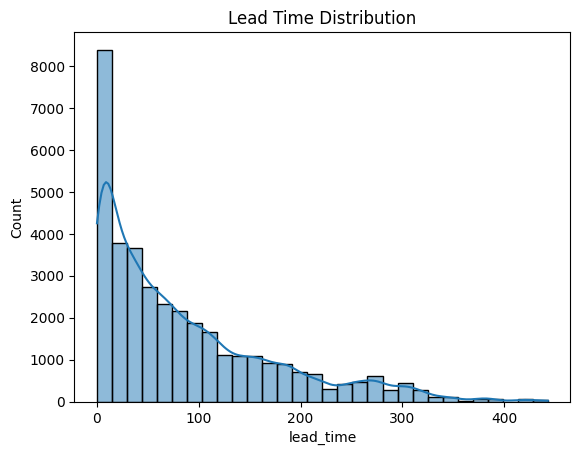

In [ ]:
sns.histplot(df['lead_time'], bins=30, kde=True)
plt.title("Lead Time Distribution")
plt.show()

avg. price per room

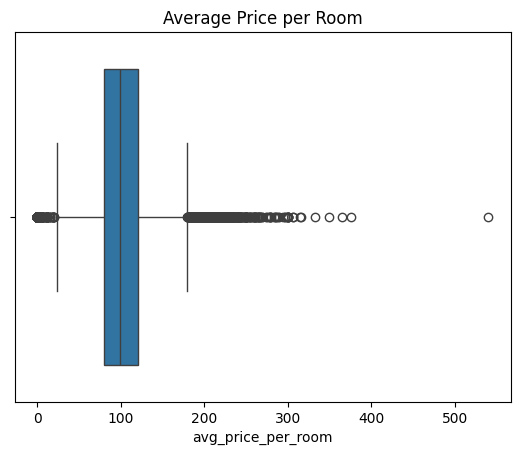

In [ ]:
sns.boxplot(x=df['avg_price_per_room'])
plt.title("Average Price per Room")
plt.show()

Bivariate Analysis

Cancellation vs Market Segment-

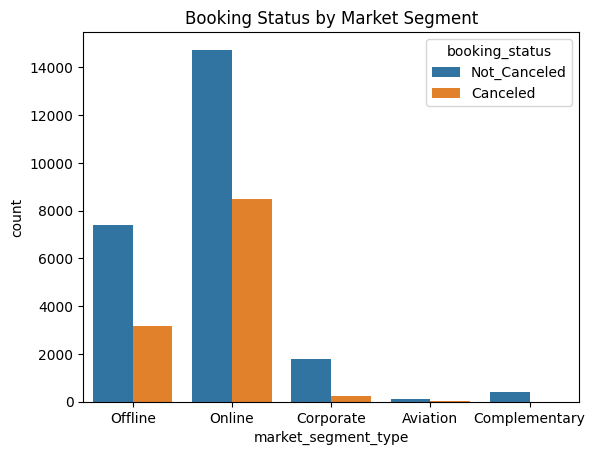

In [ ]:
sns.countplot(x='market_segment_type', hue='booking_status', data=df)
plt.title("Booking Status by Market Segment")
plt.show()

Cancellation vs Lead Time

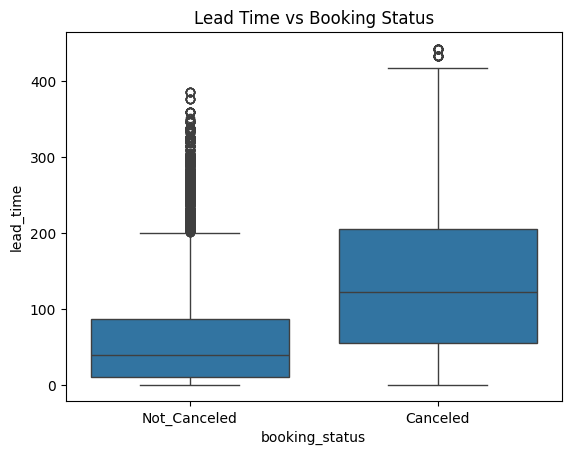

In [ ]:
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title("Lead Time vs Booking Status")
plt.show()

Cancellation vs Repeated Guest

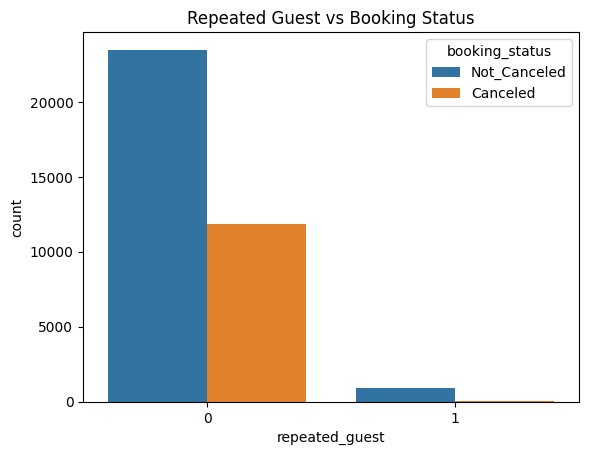

In [ ]:
sns.countplot(x='repeated_guest', hue='booking_status', data=df)
plt.title("Repeated Guest vs Booking Status")
plt.show()

Cancellation vs Special Requests

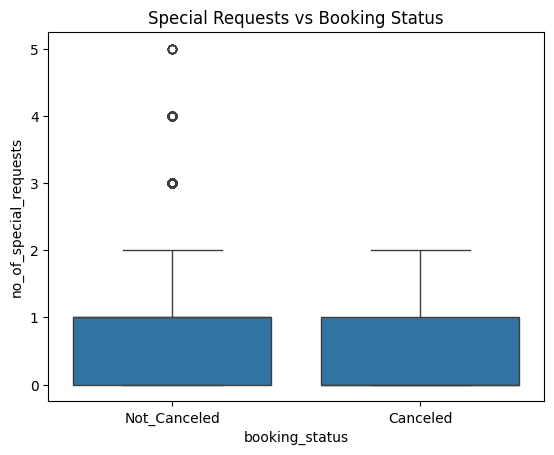

In [ ]:
sns.boxplot(x='booking_status', y='no_of_special_requests', data=df)
plt.title("Special Requests vs Booking Status")
plt.show()

Cancellation vs Room Price

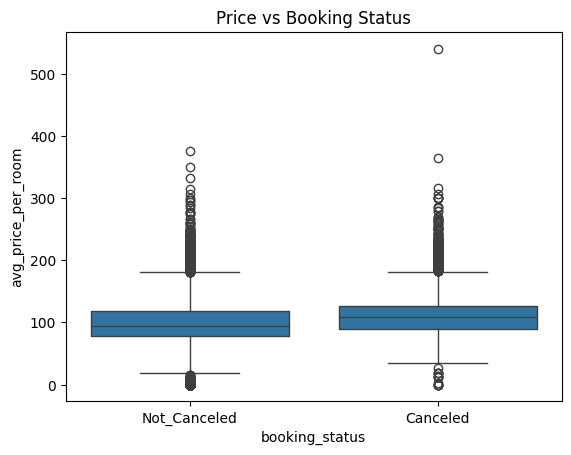

In [ ]:
sns.boxplot(x='booking_status', y='avg_price_per_room', data=df)
plt.title("Price vs Booking Status")
plt.show()

In [ ]:
df['booking_status'].value_counts(normalize=True) * 100

,proportion
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


In [ ]:
pd.crosstab(df['repeated_guest'], df['booking_status'], normalize='index') * 100

booking_status,Canceled,Not_Canceled
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


Q1)

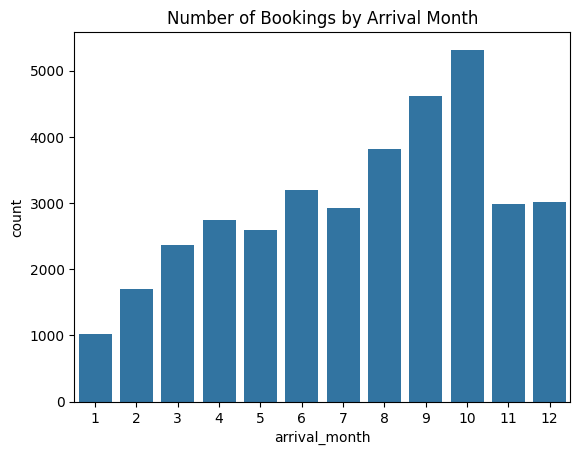

In [ ]:
sns.countplot(x='arrival_month', data=df)
plt.title("Number of Bookings by Arrival Month")
plt.show()

Q2)

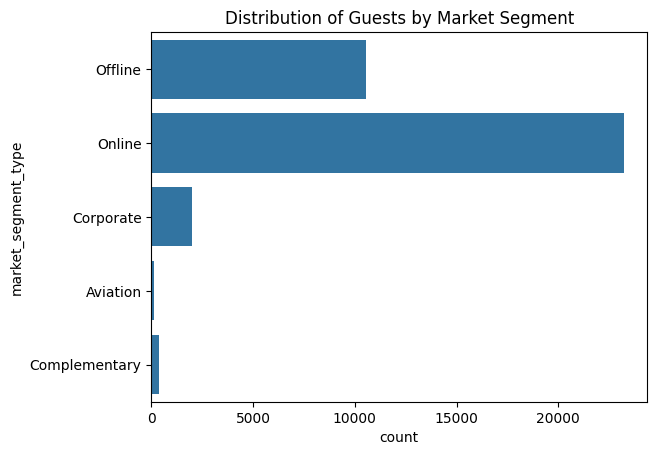

In [ ]:
sns.countplot(y='market_segment_type', data=df)
plt.title("Distribution of Guests by Market Segment")
plt.show()

Q3)

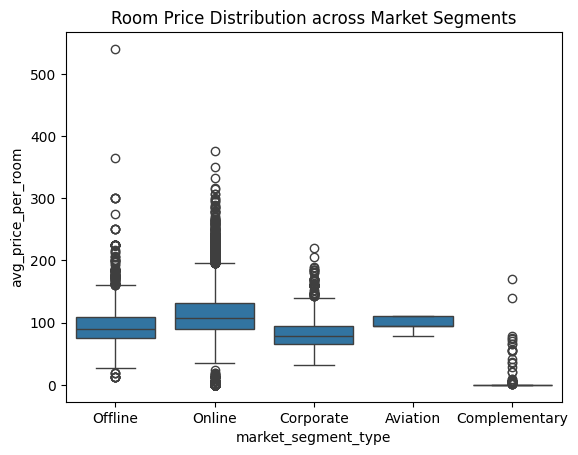

In [ ]:
sns.boxplot(x='market_segment_type', y='avg_price_per_room', data=df)
plt.title("Room Price Distribution across Market Segments")
plt.show()

Q4)

In [ ]:
df['booking_status'].value_counts(normalize=True) * 100

,proportion
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


Q5)

In [ ]:
pd.crosstab(df['repeated_guest'], df['booking_status'], normalize='index') * 100

booking_status,Canceled,Not_Canceled
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


**Data Preprocessing**

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


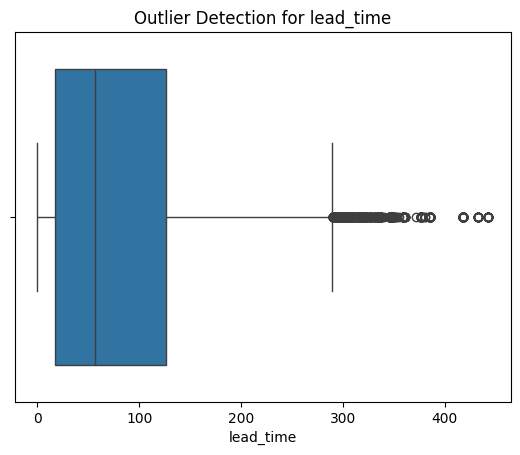

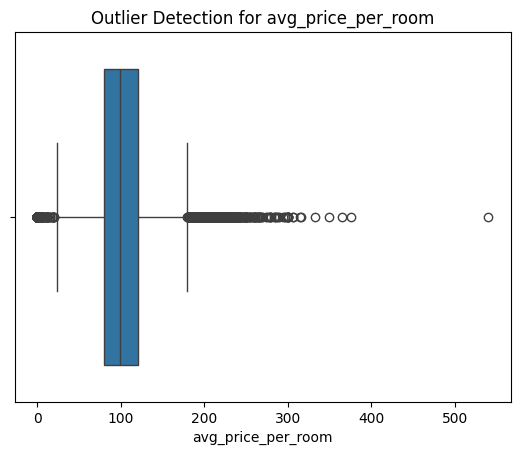

In [ ]:
num_cols = ['lead_time', 'avg_price_per_room']
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

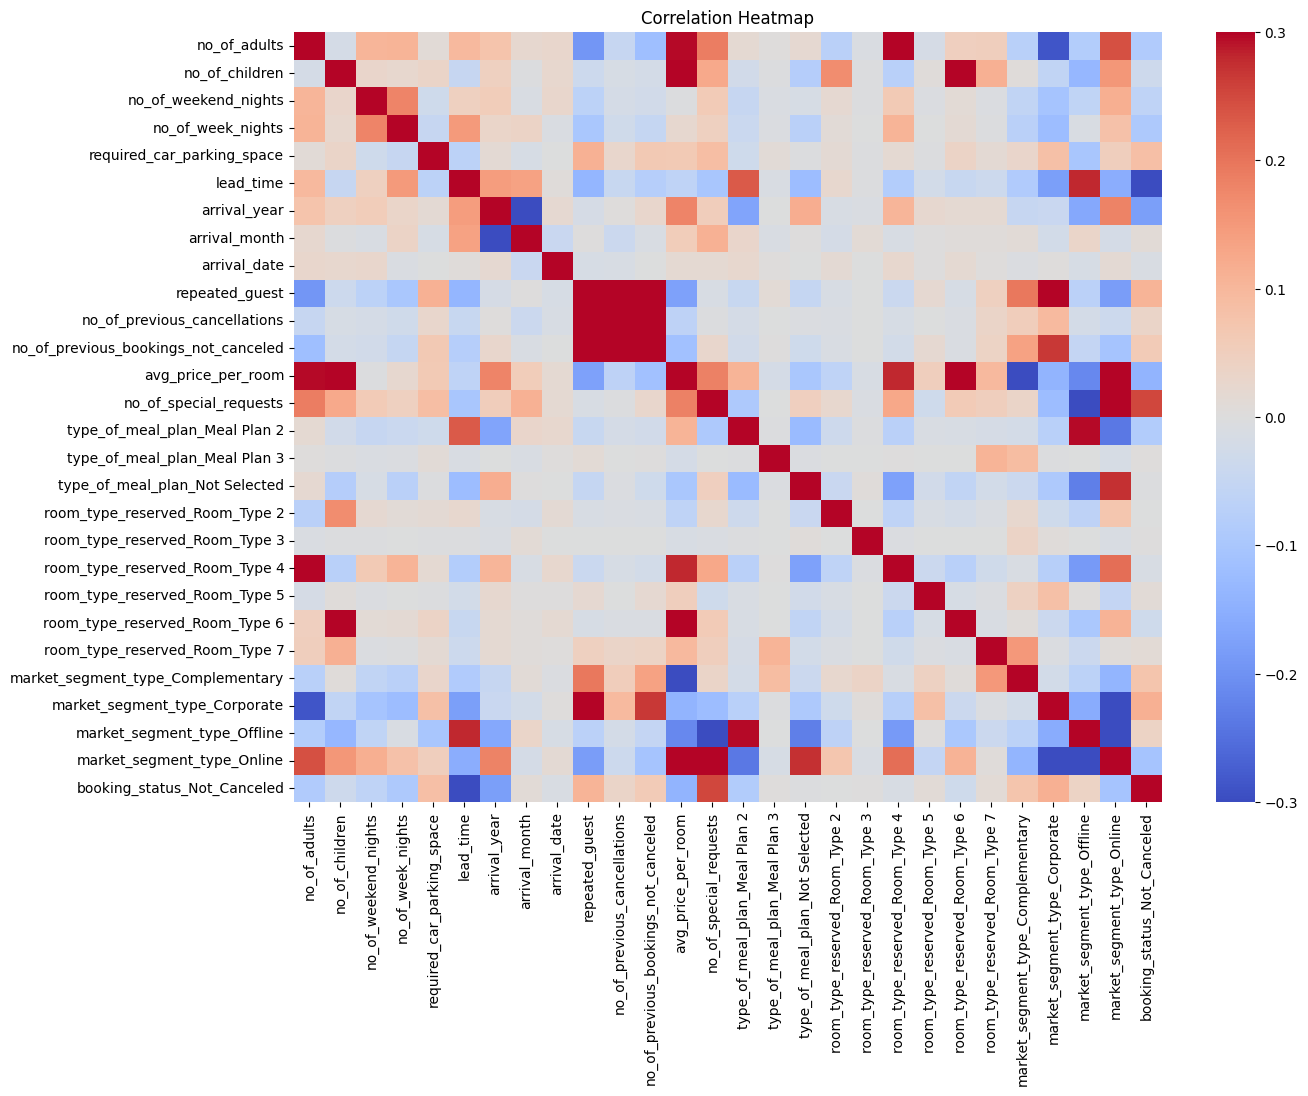

In [ ]:
corr = df_model.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-0.3, vmax=0.3)
plt.title("Correlation Heatmap")
plt.show()

Encoding

In [ ]:
df_model = df.drop("Booking_ID", axis=1)
df_model = pd.get_dummies(df_model, drop_first=True)

y = df_model["booking_status_Not_Canceled"]
X = df_model.drop("booking_status_Not_Canceled", axis=1)

**Model Building**

Logistic Regression(sklearn)-

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop('booking_status_Not_Canceled', axis=1)
y = df_model['booking_status_Not_Canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

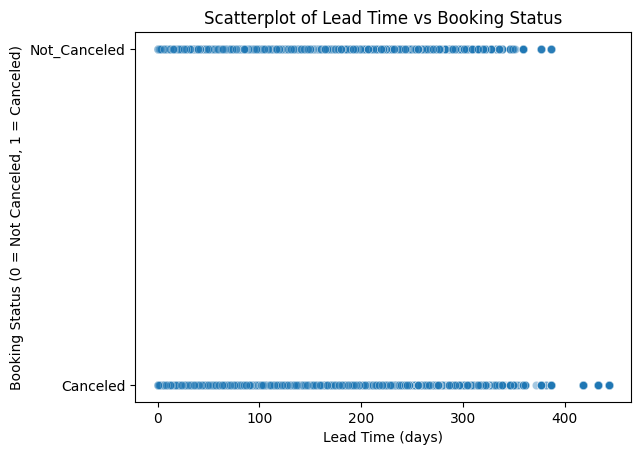

In [ ]:
sns.scatterplot(
    x=df['lead_time'],
    y=df['booking_status'],
    alpha=0.4
)
plt.xlabel("Lead Time (days)")
plt.ylabel("Booking Status (0 = Not Canceled, 1 = Canceled)")
plt.title("Scatterplot of Lead Time vs Booking Status")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("Accuracy (default threshold = 0.5):",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy (default threshold = 0.5): 0.8093356611228522

Confusion Matrix:
[[2268 1298]
 [ 777 6540]]

Classification Report:
              precision    recall  f1-score   support

       False       0.74      0.64      0.69      3566
        True       0.83      0.89      0.86      7317

    accuracy                           0.81     10883
   macro avg       0.79      0.76      0.77     10883
weighted avg       0.81      0.81      0.81     10883



Logistic regression(statsmodel)

In [39]:
df = df.sample(n=20000, random_state=42)
df["booking_status"] = df["booking_status"].map(
    {"Not_Canceled": 0, "Canceled": 1}
)

In [40]:
df = df[
    [
        "no_of_adults",
        "no_of_children",
        "no_of_weekend_nights",
        "no_of_week_nights",
        "required_car_parking_space",
        "lead_time",
        "arrival_month",
        "repeated_guest",
        "no_of_previous_cancellations",
        "avg_price_per_room",
        "no_of_special_requests",
        "type_of_meal_plan",
        "room_type_reserved",
        "market_segment_type",
        "booking_status"
    ]
]

In [41]:
X = df.drop("booking_status", axis=1)
y = df["booking_status"]

Encoding-

In [42]:
X = pd.get_dummies(
    X,
    columns=[
        "type_of_meal_plan",
        "room_type_reserved",
        "market_segment_type"
    ],
    drop_first=True
)

Train & test

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train = sm.add_constant(X_train, has_constant="add")

X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
y_train = y_train.astype(int)
X_test = sm.add_constant(X_test, has_constant="add")
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

y_test = y_test.astype(int)

X_test_np = np.asarray(X_test, dtype=float)
y_test_np = np.asarray(y_test, dtype=float)

In [50]:
logit = sm.Logit(
    np.asarray(y_train, dtype=float),
    np.asarray(X_train, dtype=float)
)

lg = logit.fit(disp=False, maxiter=200)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                14000
Model:                          Logit   Df Residuals:                    13975
Method:                           MLE   Df Model:                           24
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.3222
Time:                        10:43:36   Log-Likelihood:                -6009.8
converged:                       True   LL-Null:                       -8866.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2652      0.356     -6.368      0.000      -2.962      -1.568
x1             0.0459      0.050      0.926      0.354      -0.051       0.143
x2             0.0742      0.082      0.909      0.3

In [51]:
y_pred_prob_full = lg.predict(X_test_np)
y_pred_full = (y_pred_prob_full >= 0.5).astype(int)

from sklearn.metrics import accuracy_score

accuracy_full = accuracy_score(y_test_np, y_pred_full)
print("Accuracy (Full Model):", accuracy_full)

Accuracy (Full Model): 0.81


Using P-values

In [35]:
cols_to_remove = [
    "no_of_adults",
    "no_of_children",
    "no_of_previous_cancellations",
    "type_of_meal_plan_Meal Plan 2",
    "type_of_meal_plan_Meal Plan 3",
    "room_type_reserved_Room_Type 3",
    "market_segment_type_Complementary"
]

X_train_reduced = X_train.drop(columns=cols_to_remove)

In [36]:
X_train_reduced_np = np.asarray(X_train_reduced, dtype=float)

logit = sm.Logit(y_train_np, X_train_reduced_np)
lg_final = logit.fit(disp=False, maxiter=200)

print(lg_final.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                14000
Model:                          Logit   Df Residuals:                    13982
Method:                           MLE   Df Model:                           17
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.3211
Time:                        10:33:02   Log-Likelihood:                -6019.1
converged:                       True   LL-Null:                       -8866.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8282      0.325     -8.708      0.000      -3.465      -2.192
x1             0.1451      0.026      5.496      0.000       0.093       0.197
x2             0.0388      0.016      2.410      0.0

In [61]:
X_test_reduced = X_test.drop(columns=cols_to_remove)

In [62]:
X_test_reduced = X_test_reduced.reindex(
    columns=X_train_reduced.columns,
    fill_value=0
)

X_test_reduced_np = np.asarray(X_test_reduced, dtype=float)
y_test_np = np.asarray(y_test, dtype=float)

In [63]:
from sklearn.metrics import accuracy_score

y_pred_prob_final = lg_final.predict(X_test_reduced_np)
y_pred_final = (y_pred_prob_final >= 0.5).astype(int)

accuracy_final = accuracy_score(y_test_np, y_pred_final)
print("Accuracy finally:", accuracy_final)

Accuracy finally: 0.8106666666666666


MULTICOLLINEARITY CHECK

In [ ]:
vif = pd.DataFrame()
vif["Feature"] = X_train_reduced.columns
vif["VIF"] = [
    variance_inflation_factor(X_train_reduced.values, i)
    for i in range(X_train_reduced.shape[1])
]

vif

,Feature,VIF
0,const,3.244315e+07
1,no_of_children,1.939121e+00
2,no_of_weekend_nights,1.055654e+00
3,no_of_week_nights,1.090423e+00
4,required_car_parking_space,1.037460e+00
5,lead_time,1.263604e+00
6,arrival_year,1.177380e+00
7,arrival_date,1.004488e+00
8,repeated_guest,1.478463e+00
9,no_of_previous_cancellations,1.178734e+00


ROC CURVE & AUC

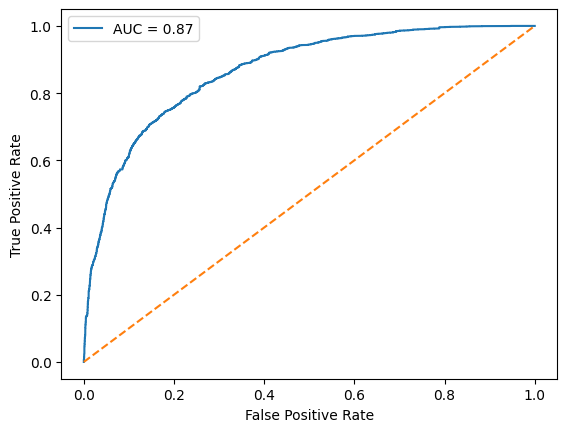

In [ ]:
X_test_reduced = sm.add_constant(
    X_test[X_train_reduced.columns[1:]]
)

y_prob = result.predict(X_test_reduced)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
optimal_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_index]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.35631128675930646


Decision Tree Classifier-

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
X = df.drop(["booking_status", "Booking_ID"], axis=1)
y = df["booking_status"]

In [ ]:
cat_cols = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type",
    "arrival_month"
]

le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y )

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.870768552210828
[[2396  575]
 [ 597 5501]]
              precision    recall  f1-score   support

    Canceled       0.80      0.81      0.80      2971
Not_Canceled       0.91      0.90      0.90      6098

    accuracy                           0.87      9069
   macro avg       0.85      0.85      0.85      9069
weighted avg       0.87      0.87      0.87      9069



Pre-pruning

In [ ]:
dt_pre_pruned = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_pre_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred_pre = dt_pre_pruned.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_pre))
print(confusion_matrix(y_test, y_pred_pre))
print(classification_report(y_test, y_pred_pre))

Accuracy: 0.8451869004300364
[[2087  884]
 [ 520 5578]]
              precision    recall  f1-score   support

    Canceled       0.80      0.70      0.75      2971
Not_Canceled       0.86      0.91      0.89      6098

    accuracy                           0.85      9069
   macro avg       0.83      0.81      0.82      9069
weighted avg       0.84      0.85      0.84      9069



Post-pruning

In [ ]:
path = dt_pre_pruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [ ]:
dt_models = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )
    model.fit(X_train, y_train)
    dt_models.append(model)

In [ ]:
acc_scores = [
    accuracy_score(y_test, model.predict(X_test))
    for model in dt_models
]

best_alpha = ccp_alphas[np.argmax(acc_scores)]
best_alpha

np.float64(0.00011116881076716784)

In [ ]:
dt_post_pruned = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

dt_post_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00011116881076716784),
                       random_state=42)

In [ ]:
y_pred_post = dt_post_pruned.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_post))
print(confusion_matrix(y_test, y_pred_post))
print(classification_report(y_test, y_pred_post))

Final Accuracy: 0.883559378101224
[[2304  667]
 [ 389 5709]]
              precision    recall  f1-score   support

    Canceled       0.86      0.78      0.81      2971
Not_Canceled       0.90      0.94      0.92      6098

    accuracy                           0.88      9069
   macro avg       0.88      0.86      0.86      9069
weighted avg       0.88      0.88      0.88      9069

